<a href="https://colab.research.google.com/github/kosebaris1/MACHINE_LEARNING/blob/denoising-autoencoder-rbm/RBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Eğitim boyutu: (1437, 64)
Test boyutu: (360, 64)

=== RBM Boyut Karşılaştırması (32-64-128) ===


---- RBM n_components = 32 ----
RBM=32 → MSE=0.0465, Accuracy=0.8028

---- RBM n_components = 64 ----
RBM=64 → MSE=0.0476, Accuracy=0.8194

---- RBM n_components = 128 ----
RBM=128 → MSE=0.0528, Accuracy=0.8194

=== RBM'siz Logistic Regression (Ham Piksel) ===
Ham Piksel Accuracy = 0.9667

Karşılaştırma:
RBM(32) Accuracy = 0.8028  |  Ham Piksel = 0.9667
RBM(64) Accuracy = 0.8194  |  Ham Piksel = 0.9667
RBM(128) Accuracy = 0.8194  |  Ham Piksel = 0.9667

=== Confusion Matrix (RBM-64) ===


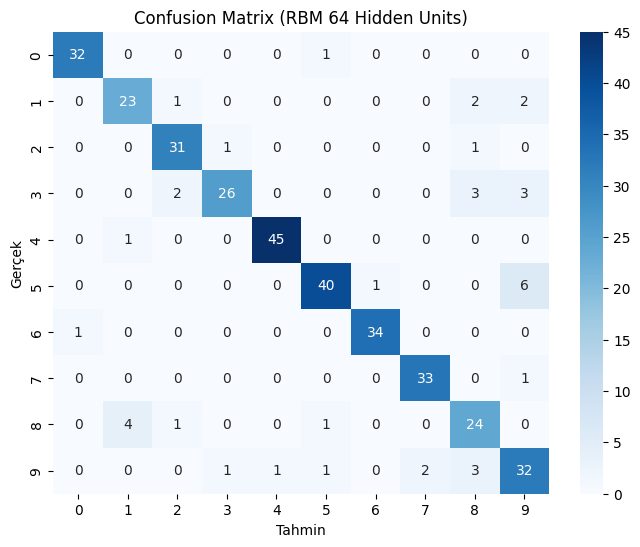

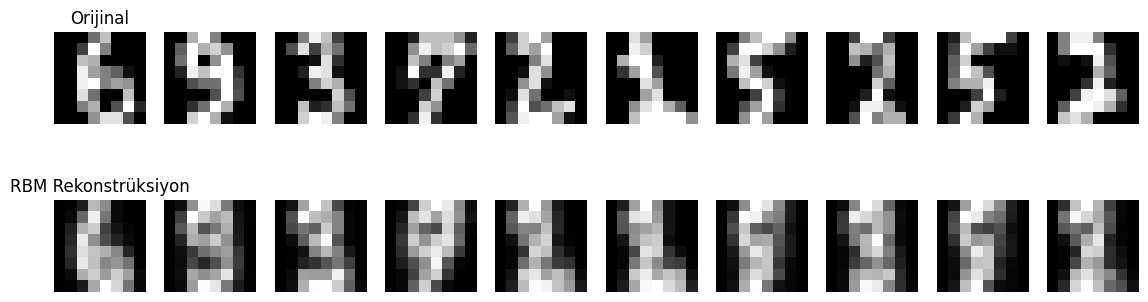

In [4]:
#Hocam modelin davranışını daha iyi değerlendirmek ve sonuçları daha anlamlı hale getirmek amacıyla üç adet ek analiz ekledim.
#1-)RBM'in performansı şeçilen gizli katman boyutuna doğrudan bağlı olduğu için farklı gizli katman(32-64-128) boyutları ekledim ve karşılaştırdım.Yani amacım farklı boyutların MSE ve sınıflandırma üzerindeki etkisini vurgulamaktı
#RBM'in kapasitesinin nasıl değiştiğini,
#gizli katman sayısı arttıkça rekonstrüksiyonun nasıl iyileştiğini,
#hangi boyutun daha uygun olduğunu göstermek

#2-)RBM’siz Logistic Regression ile Accuracy karşılaştırması ekledim.Ekleme amacı da RBM'in(özellik çıkarıcı) nasıl davrandığını daha iyi görmek.

#3-)Confusion Matrix eklenmesi(RBM-64 modeli için)
#Confusion matrix, yalnızca accuracy değerine bakmak yerine:
# - Hangi rakamların doğru sınıflandırıldığını,
# - Hangi rakamların birbiriyle karıştığını,
# - Modelin zayıf noktalarını
# görsel olarak daha kolay anlamayı sağlar.

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import BernoulliRBM
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 4)



# 1) Veri Seti
digits = load_digits()
X = digits.data
y = digits.target


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Eğitim boyutu:", X_train.shape)
print("Test boyutu:", X_test.shape)



# 2)Manuel sigmoid
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))



# 3) Farklı gizli katman boyutlarını (32–64–128) karşılaştırma
hidden_sizes = [32, 64, 128]

print("\n=== RBM Boyut Karşılaştırması (32-64-128) ===\n")

results = []

for h in hidden_sizes:
    print(f"\n---- RBM n_components = {h} ----")

    rbm = BernoulliRBM(
        n_components=h,
        learning_rate=0.05,
        n_iter=10,
        batch_size=10,
        random_state=42,
        verbose=False
    )

    rbm.fit(X_train)


    X_test_hidden = rbm.transform(X_test)
    X_train_hidden = rbm.transform(X_train)


    X_test_recon = sigmoid(
        np.dot(X_test_hidden, rbm.components_) + rbm.intercept_visible_
    )

    mse = mean_squared_error(X_test, X_test_recon)


    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_hidden, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_hidden))

    results.append((h, mse, acc))
    print(f"RBM={h} → MSE={mse:.4f}, Accuracy={acc:.4f}")




# 4) RBM'siz Logistic Regression (baseline)
print("\n=== RBM'siz Logistic Regression (Ham Piksel) ===")

clf_raw = LogisticRegression(max_iter=2000)
clf_raw.fit(X_train, y_train)
y_pred_raw = clf_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

print(f"Ham Piksel Accuracy = {acc_raw:.4f}\n")

print("Karşılaştırma:")
for h, mse, acc in results:
    print(f"RBM({h}) Accuracy = {acc:.4f}  |  Ham Piksel = {acc_raw:.4f}")



# 5) Confusion Matrix (RBM 64 boyutlu için)
print("\n=== Confusion Matrix (RBM-64) ===")

# RBM 64 model eğitimi
rbm64 = BernoulliRBM(n_components=64, learning_rate=0.05, n_iter=20, random_state=42)
rbm64.fit(X_train)

# Özellik çıkarımı
X_train_h = rbm64.transform(X_train)
X_test_h = rbm64.transform(X_test)

clf64 = LogisticRegression(max_iter=2000)
clf64.fit(X_train_h, y_train)

y_pred_64 = clf64.predict(X_test_h)

cm = confusion_matrix(y_test, y_pred_64)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix (RBM 64 Hidden Units)")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()


# 6) Orijinal vs Rekonstrüksiyon gösterimi (RBM-64)
X_test_hidden = rbm64.transform(X_test)
X_test_reconstructed = sigmoid(
    np.dot(X_test_hidden, rbm64.components_) + rbm64.intercept_visible_
)

num_images = 10
fig, axes = plt.subplots(2, num_images, figsize=(14, 4))

for i in range(num_images):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(X_test_reconstructed[i].reshape(8, 8), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Orijinal")
axes[1, 0].set_title("RBM Rekonstrüksiyon")
plt.show()
